Лучшая начальная разница потенциалов (минимальная) 8.600117266178131
Время полета 6e-08
Время полета 1107625.214838477


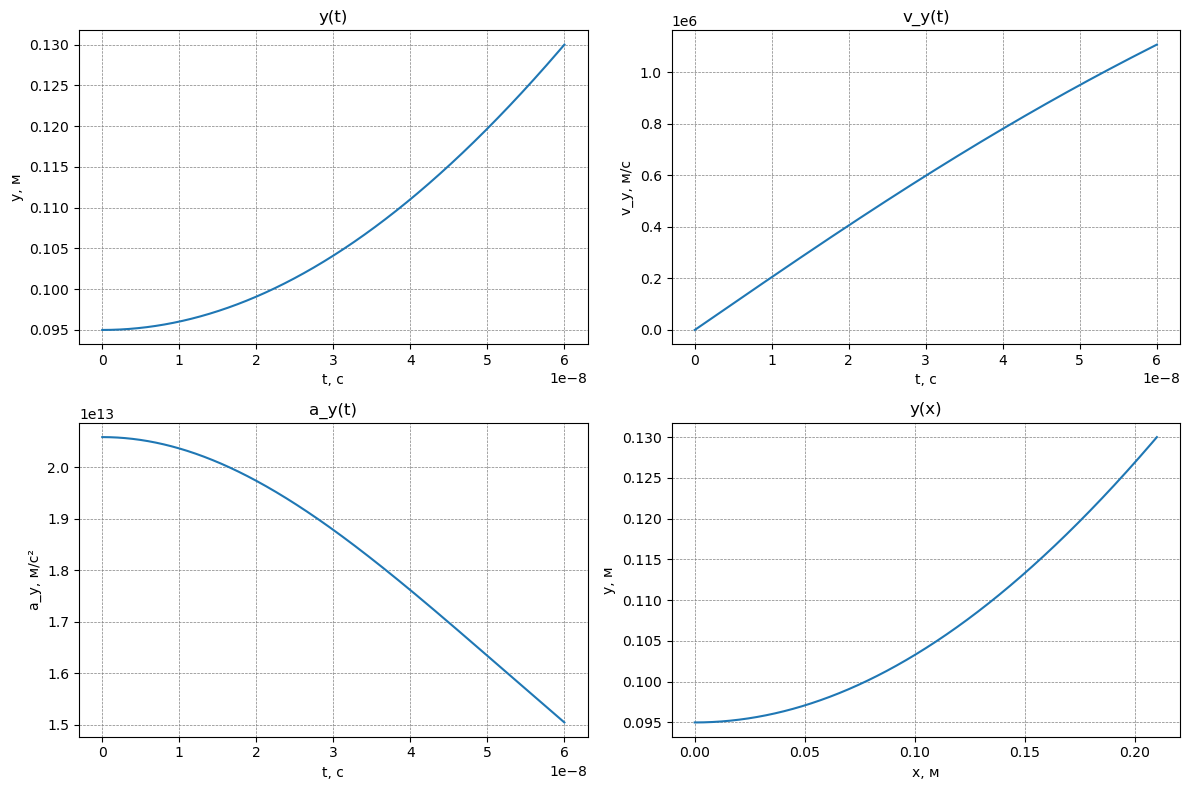

In [52]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Константы
q_e = 1.6e-19          # Кл (заряд электрона)
m_e = 9.1e-31          # кг (масса электрона)
Delta_phi = 200      # В (разность потенциалов, выбрана для примера)
R1 = 0.06              # м (внешний радиус)
R2 = 0.13              # м (внутренний радиус)
V = 3.5 * 1e6                # м/с (начальная скорость вдоль оси x)
L = 0.21                # м (длина конденсатора)
y0 = (R1 + R2) / 2     # Начальная позиция
v_y0 = 0               # Начальная скорость вдоль оси y
log_R = np.log(R2 / R1)  # Логарифм отношения радиусов
precision = 1e-6

# дифур для ускорения
def equations(t, yv):
    y, v_y = yv
    a_y = q_e * Delta_phi / (m_e * y * log_R)
    return [v_y, a_y]

# Время полета (максимальное т.к. нам нужно найти минимальное delta phi)
t_0 = L / V
t_span = (0, t_0)

t_eval = np.linspace(*t_span, 10000)

# Начальные условия: [y0, v_y0]
y0_v0 = [y0, v_y0]

step = Delta_phi
while step > precision:
    # Решение системы дифференциальных уравнений
    sol = solve_ivp(equations, t_span, y0_v0, t_eval=t_eval)
    
    # Получаем результаты
    t = sol.t
    y = sol.y[0]
    v_y = sol.y[1]
    if y[-1] > R2:
        Delta_phi -= step
    else:
        Delta_phi += step
    step /= 2

print('Лучшая начальная разница потенциалов (минимальная)', Delta_phi)
print('Время полета', t_0)
print('Время полета', v_y[-1])

# Ускорение как функция времени
a_y = q_e * Delta_phi / (m_e * y * log_R)

# Зависимость y от x
x = V * t

# Построение графиков
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.grid(True, linestyle='--', color='gray', linewidth=0.5)
plt.plot(t, y)
plt.title('y(t)')
plt.xlabel('t, с')
plt.ylabel('y, м')

plt.subplot(2, 2, 2)
plt.grid(True, linestyle='--', color='gray', linewidth=0.5)
plt.plot(t, v_y)
plt.title('v_y(t)')
plt.xlabel('t, с')
plt.ylabel('v_y, м/с')

plt.subplot(2, 2, 3)
plt.grid(True, linestyle='--', color='gray', linewidth=0.5)
plt.plot(t, a_y)
plt.title('a_y(t)')
plt.xlabel('t, с')
plt.ylabel('a_y, м/с²')

plt.subplot(2, 2, 4)
plt.grid(True, linestyle='--', color='gray', linewidth=0.5)
plt.plot(x, y)
plt.title('y(x)')
plt.xlabel('x, м')
plt.ylabel('y, м')

plt.tight_layout()
plt.savefig('mod2.png')
plt.show()